# 📊 Exploratory Data Analysis (EDA) Plan

*Statistical Characterization of the PTB-XL Dataset*

---

## 🎯 Objectives of EDA

The purpose of EDA is to:

1. Understand population characteristics
2. Quantify label distribution and imbalance
3. Assess signal properties
4. Identify potential sources of bias
5. Inform modeling and validation strategy

EDA is not visualization for aesthetics — it is **pre-model statistical reconnaissance**.

---

# 1️⃣ Cohort Characterization

## 1.1 Sample Size

* Total number of ECG recordings
* Total number of unique patients
* Recordings per patient distribution

**Why it matters:**
Prevents patient-level data leakage and informs split strategy.

---

## 1.2 Demographics

### Age

* Mean ± SD
* Median (IQR)
* Histogram
* Age bins (e.g., <40, 40–60, >60)

### Sex

* Counts and percentages
* Bar plot

**Why it matters:**
Enables subgroup analysis and bias assessment.

---

# 2️⃣ Label Distribution Analysis

PTB-XL is multi-label.

## 2.1 Diagnostic Superclasses

Compute:

* Count per class
* Prevalence (%)
* Co-occurrence matrix

Display:

* Bar plot of class frequencies
* Heatmap of label co-occurrence

**Why it matters:**

* Detects severe imbalance
* Guides weighted loss design
* Informs macro vs micro metric choice

---

## 2.2 Label Cardinality

* Average number of labels per ECG
* Distribution of label counts

This tells you:

* How multi-label the dataset actually is

---

# 3️⃣ Signal-Level Analysis

(Using 500 Hz or 100 Hz data)

## 3.1 Signal Length

* Confirm uniform length
* Check for missing or corrupted files

## 3.2 Amplitude Distribution

* Mean amplitude per lead
* Standard deviation per lead
* Outlier detection

## 3.3 Lead Correlation

* Correlation matrix between leads
* Detect redundancy or abnormal signals

---

# 4️⃣ Missingness Analysis

* Missing demographic data
* Missing labels
* Missing signals

If present:

* Quantify proportion
* Determine missingness pattern (MCAR/MAR suspicion)

---

# 5️⃣ Train/Test Split Validation

Before training:

* Confirm patient-level split
* Compare:

  * Age distribution (train vs test)
  * Sex distribution
  * Label prevalence

Use:

* t-test or Mann–Whitney (age)
* Chi-square test (sex, labels)

**Goal:** Ensure no distributional shift between splits.

---

# 6️⃣ Class Imbalance Quantification

Compute:

* Imbalance ratio (max/min class frequency)
* Effective number of samples (for weighted loss)

Decide:

* Class weights
* Focal loss?
* Threshold tuning strategy?

---

# 7️⃣ Correlation Between Demographics and Labels

Example analyses:

* Age vs MI prevalence
* Sex vs conduction disorders

Use:

* Logistic regression (univariate)
* Odds ratios with 95% CI

This gives you publishable-level descriptive stats.

---

# 📈 Key Tables to Produce

| Table   | Description                           |
| ------- | ------------------------------------- |
| Table 1 | Baseline Demographics                 |
| Table 2 | Diagnostic Class Prevalence           |
| Table 3 | Label Co-occurrence Matrix            |
| Table 4 | Train vs Test Distribution Comparison |

---

# 🧠 Statistical Framing

EDA is answering:

* Is the dataset representative?
* Is it balanced?
* Is it suitable for macro-AUC evaluation?
* Are there confounders?
* Will subgroup analysis be powered?

---

# 🚨 Red Flags to Look For

* Extreme class imbalance (<1%)
* One sex dominating a diagnostic label
* Age skew in test set
* Highly correlated labels
* Duplicate patients across splits

In [84]:
# --------------------------------------------------
# Importing necessary libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import wfdb

## 1️⃣ Load the Data

In [85]:
# --------------------------------------------------
# Setting up paths
# --------------------------------------------------
file_path = "../data/ptbxl_database.csv"
df = pd.read_csv(file_path, sep=",", index_col='ecg_id')

# print basic info about the dataframe
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  object 
 8   recording_date                21799 non-null  object 
 9   report                        21799 non-null  object 
 10  scp_codes                     21799 non-null  object 
 11  heart_axis                    13331 non-null  object 
 12  infarction_stadium1           5612 non-null   object 
 13  infarc

In [86]:
df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


# 2️⃣ Diagnostic Labels

The diagnostic Labels are in a format where more than 1 condition can be present based on the ECG and cardiologist interpretation. These classifications are the scp codes. The possible scp codes are `['NORM','MI','STTC','CD','HYP']`. These are the five major dignostic superclasses used to classify ECG signals. 
* NORM: Normal ECG
* MI (Myocardial Infarction): Indicates heart attacks. 
* STTC (ST/T Change): Indicates abnormalitioes in the ST segment or the T wave. 
* CD (Conduction Disturbance): Disturbances in the heart's electrical conduction system.
* HYP (Hypertrophy): Enlargement of the heart muscle. 

Source: [PubMed, Deep Learning Models for Arrhythmia Classification Based on ECG Signals Using PTB-X Dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC12346745/)

Need to encode these classifications which act as our ground truth through Multilabel Encoder.

In [87]:
# -- 2. Load SCP statements & filter to diagnostic only --
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Load SCP statements to get superclass mappings
agg_df = pd.read_csv('../data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# -- 3. Map SCP Codes -> Diagnostic superclass
def get_superclass(scp_dict):
    classes = []
    # Loop through the scp_dict for an ECG interpretation
    for key in scp_dict.keys():
        # Add present SCP codes under a new column called diagnostic_class and store it into classes 
        if key in agg_df.index:
            classes.append(agg_df.loc[key, 'diagnostic_class'])
    return list(set(classes))

df['superclass'] = df['scp_codes'].apply(get_superclass)
df = df[df['superclass'].map(len) > 0]  # drop records with no diagnostic label

print(df['superclass'].value_counts())

superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[CD, MI]               1297
[STTC, HYP]             781
[MI, STTC]              599
[HYP]                   535
[CD, STTC]              471
[CD, NORM]              407
[MI, STTC, HYP]         361
[CD, HYP]               300
[CD, MI, STTC]          223
[CD, STTC, HYP]         211
[MI, HYP]               183
[CD, MI, STTC, HYP]     156
[CD, MI, HYP]           117
[NORM, STTC]             28
[CD, NORM, STTC]          5
[CD, NORM, HYP]           2
[NORM, HYP]               2
[CD, NORM, MI, HYP]       1
Name: count, dtype: int64


In [89]:
from sklearn.preprocessing import MultiLabelBinarizer
# -- 4. Apply Multilabel Binarizer --

# Encode the SCP codes where 1 indictaes condition is present and 0 indictes it is not
mlb = MultiLabelBinarizer(classes=['NORM','MI','STTC','CD','HYP'])
Y = mlb.fit_transform(df['superclass']) # The shape should be (N, 5)
print(Y.shape)

(21388, 5)


In [91]:
# ---------------------------------------------------
# Sanity Checks on the extracted superclasses
# ---------------------------------------------------

# Check how many ECGs have at least one diagnostic label
n_with_labels = (df["superclass"].apply(len) > 0).sum()
n_total = len(df)

print(f"ECGs with diagnostic labels: {n_with_labels}/{n_total}")
print(f"Percentage labeled: {100 * n_with_labels / n_total:.2f}%")

# Check for empty labels
empty_labels = df[df["superclass"].apply(len) == 0]
print("Number of ECGs with NO diagnostic superclass:", len(empty_labels))

ECGs with diagnostic labels: 21388/21388
Percentage labeled: 100.00%
Number of ECGs with NO diagnostic superclass: 0


In [92]:
# Count the occurrences of each superclass
all_classes = [cls for sublist in df["superclass"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()

print("\nDiagnostic Superclass Counts:")
print(class_counts)


Diagnostic Superclass Counts:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


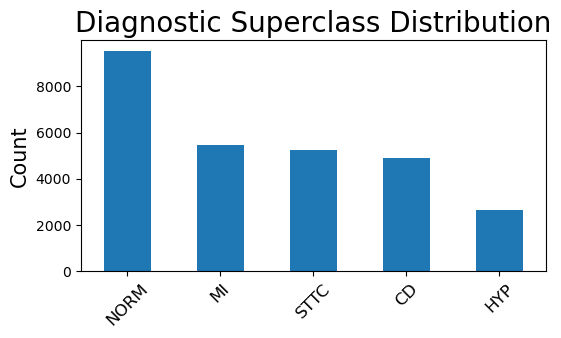

In [93]:
# -- Make a figure showing the Superclass Distributions --
plt.figure(figsize=(6, 3), facecolor='white')

# Define fontsizes
label = 15 
title = 20 
ticks = 12

# Plot class_counts
class_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution", fontsize=title)
plt.ylabel("Count", fontsize=label)
plt.xticks(rotation=45, fontsize=ticks)
plt.show()

## Generate Table 1 

In [96]:
# -- Generate Table 1: Summary Statistics --

# Cohort size
n_records  = df.shape[0]
n_patients = df['patient_id'].nunique()

# Age - correct HIPAA-compliant encoding (age > 89 stored as 300)
df.loc[df['age'] >= 89, 'age'] = 90

age_mean   = df['age'].mean()
age_sd     = df['age'].std()
age_median = df['age'].median()
age_q1     = df['age'].quantile(0.25)
age_q3     = df['age'].quantile(0.75)

# Sex - PTB-XL encodes 0 = female, 1 = male
sex_counts  = df['sex'].value_counts().rename({0: 'Female', 1: 'Male'}).sort_index()
sex_percent = sex_counts / n_records * 100

# Diagnostic superclasses (multi-label: % of records containing each class)
all_classes   = [cls for sublist in df['superclass'] for cls in sublist]
class_counts  = pd.Series(all_classes).value_counts()
class_percent = class_counts / n_records * 100

# -- Build Table 1 --
table1_rows = []

table1_rows.append(["Total ECG Recordings", f"{n_records:,}"])
table1_rows.append(["Unique Patients",       f"{n_patients:,}"])

table1_rows.append(["Age (years), mean ± SD",
                    f"{age_mean:.1f} ± {age_sd:.1f}"])
table1_rows.append(["Age (years), median (IQR)",
                    f"{age_median:.1f} ({age_q1:.1f}–{age_q3:.1f})"])

for sex in sex_counts.index:
    table1_rows.append([f"Sex: {sex}",
                        f"{sex_counts[sex]:,} ({sex_percent[sex]:.1f}%)"])

for cls in class_counts.index:
    table1_rows.append([f"Diagnosis: {cls}",
                        f"{class_counts[cls]:,} ({class_percent[cls]:.1f}%)"])

table1 = pd.DataFrame(table1_rows, columns=["Characteristic", "Value"])
table1

,Characteristic,Value
0,Total ECG Recordings,"21,388"
1,Unique Patients,"18,617"
2,"Age (years), mean ± SD",59.8 ± 17.0
3,"Age (years), median (IQR)",62.0 (50.0–72.0)
4,Sex: Female,"11,111 (51.9%)"
5,Sex: Male,"10,277 (48.1%)"
6,Diagnosis: NORM,"9,514 (44.5%)"
7,Diagnosis: MI,"5,469 (25.6%)"
8,Diagnosis: STTC,"5,235 (24.5%)"
9,Diagnosis: CD,"4,898 (22.9%)"


## Generate Table 2

In [101]:
# Flatten labels
all_classes   = [cls for sublist in df['superclass'] for cls in sublist]  # was 'superclasses'
class_counts  = pd.Series(all_classes).value_counts()
class_percent = class_counts / n_records * 100

# Explode so each row = one superclass label
df_exploded = df[['patient_id', 'age', 'sex', 'superclass']].explode('superclass')  # was 'superclasses'

# Drop null labels
null_labels = df_exploded['superclass'].isnull().sum()  # was 'superclasses'
print(f"Number of null labels before dropping: {null_labels}")
df_exploded = df_exploded.dropna(subset=['superclass'])  # was 'superclasses'

# Unique patients per superclass
patient_counts = (
    df_exploded.groupby('superclass')['patient_id']  # was 'superclasses'
    .nunique()
    .sort_values(ascending=False)
)

# Sex breakdown per superclass
sex_stats = (
    df_exploded.groupby('superclass')['sex']  # was 'superclasses'
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=['Female', 'Male'], fill_value=0)
)
sex_stats['female_percent'] = sex_stats['Female'] * 100
sex_stats['male_percent']   = sex_stats['Male']   * 100

# Age statistics per superclass
age_stats = (
    df_exploded.groupby('superclass')['age']  # already correct, was the only one right before
    .agg(
        median_age='median',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# % of total patients with each superclass
n_patients      = df['patient_id'].nunique()
patient_percent = patient_counts / n_patients * 100

Number of null labels before dropping: 0


In [102]:
age_stats

,median_age,q1,q3
superclass,,,
CD,68.0,57.0,77.0
HYP,68.0,58.0,77.0
MI,67.0,58.0,76.0
NORM,54.0,40.0,65.0
STTC,68.0,58.0,77.0


## Generate Table 3

Its important to generate the model train, test, val splits ensuring the same patient is not found in the other splits. Essentially Patient '1' can't be in both train and test. This is to prevent subject leakage. If subject leakage occurs our models will overestimate the performance resulting in bad test and/or val performance. 

1. Split at the patient level, then assign all ECGs from that patient to the same split. 

Additionally, we want to try our best to preserve label distribution. Since this is a multilabel classification, we can not use the usual standard stratified split directly. That is because we want: 
* Similar prevalnce of NORM, MI, STTC, HYP, and CD
* Similar sex distribution
* Similar age distribution

Approach: 
1. Patient-level split
2. Multilabel stratification
3. 70% train / 15% Test / 15% Validation 

🎯 What This Achieves
* ✔ No patient leakage
* ✔ Preserves multilabel distribution
* ✔ Preserves class imbalance structure
* ✔ Scientifically defensible

In [ ]:
# from sklearn.preprocessing import MultiLabelBinarizer

# # Get patient-level superclass lists
# patient_labels = (
#     df.groupby("patient_id")["superclasses"]
#     .apply(lambda x: list(set([cls for sublist in x for cls in sublist])))
# )

# mlb = MultiLabelBinarizer()
# Y = mlb.fit_transform(patient_labels)

In [ ]:
# from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
# import numpy as np

# # ------------------------------------------------
# # Split the dataset into Train, Validation, and Test sets
# # ------------------------------------------------

# # Get patient IDs
# patients = patient_labels.index.values

# ## Create a Temporary Split of 70% Train and 30% Temp (to be further split into Validation and Test)
# # Create the MultilabelStratifiedShuffleSplit object
# msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

# train_idx, temp_idx = next(msss.split(patients, Y))

# # Get the patient IDs for each set
# train_patients = patients[train_idx]
# temp_patients = patients[temp_idx]

In [ ]:
# # ------------------------------------------------
# # Split the Temp Set into Validation and Test Sets
# # ------------------------------------------------

# # Get the corresponding labels for the temp set
# Y_temp = Y[temp_idx]

# # Create a second MultilabelStratifiedShuffleSplit object to split the temp set into validation and test sets
# msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

# val_idx, test_idx = next(msss2.split(temp_patients, Y_temp))

# # Get the patient IDs for the validation and test sets
# val_patients = temp_patients[val_idx]
# test_patients = temp_patients[test_idx]

In [ ]:
# ----------------------------
# Load splits
# ----------------------------

# Define the split folder 
splits_dir = Path("../splits")
train_patients = pd.read_csv(splits_dir / "train_patients.csv")["patient_id"].values
val_patients   = pd.read_csv(splits_dir / "val_patients.csv")["patient_id"].values
test_patients  = pd.read_csv(splits_dir / "test_patients.csv")["patient_id"].values

# ----------------------------
# Assign split column
# ----------------------------
df['split'] = "train"  # default
df.loc[df['patient_id'].isin(val_patients), 'split'] = "val" # Assign 'val' to patients in the validation set
df.loc[df['patient_id'].isin(test_patients), 'split'] = "test" # Assign 'test' to patients in the test set

# Quick check
print(df['split'].value_counts())

split
train    15275
test      3288
val       3236
Name: count, dtype: int64


In [ ]:
# # Assign the split column to the original dataframe
# df['split'] = "train"

# df.loc[df['patient_id'].isin(val_patients), 'split'] = 'val' # Assign 'val' to patients in the validation set
# df.loc[df['patient_id'].isin(test_patients), 'split'] = 'test' # Assign 'test' to patients in the test set

In [91]:
# -------------------------------------------------
# Verify the Superclass Balance 
# -------------------------------------------------
# Make sure each row corresponds to one superclass
df_exploded = df[['patient_id', 'sex_label', 'age', 'superclasses', 'split']].explode('superclasses').dropna(subset=['superclasses'])

superclass_balance = (
    df_exploded.groupby(['split', 'superclasses'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages within each split
superclass_balance_pct = superclass_balance.div(superclass_balance.sum(axis=1), axis=0) *100
print(superclass_balance_pct)

superclasses         CD       HYP         MI       NORM       STTC
split                                                             
test          17.972682  9.825066  19.482387  34.100168  18.619698
train         17.653391  9.621200  19.657594  34.173971  18.893844
val           17.242224  8.866030  20.107764  34.876316  18.907666


In [92]:
# --------------------------------------------------
# Verify the Sex Balance 
# --------------------------------------------------

sex_balance = (
    df.groupby(['split', 'sex_label'])
    .size()
    .unstack(fill_value=0)
)

# Percentages per split
sex_balance_pct = sex_balance.div(sex_balance.sum(axis=1), axis=0) * 100
print(sex_balance_pct)

sex_label       Male     Female
split                          
test       51.155718  48.844282
train      52.202946  47.797054
val        52.472188  47.527812


C:\Users\delga\AppData\Local\Temp\ipykernel_30684\2982664619.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['split', 'sex_label'])


In [93]:
patient_balance = (
    df.groupby('split')['patient_id']
    .nunique()
)
print(patient_balance)

split
test      2831
train    13208
val       2830
Name: patient_id, dtype: int64


In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def verify_split_summary(df, label_col='superclasses', sex_col='sex_label', split_col='split'):
    """
    Prints a summary table and plots distributions of labels and sex across train/test splits.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data.
        label_col (str): Column name for multilabel/class labels (exploded if multilabel).
        sex_col (str): Column name for sex.
        split_col (str): Column indicating 'train' or 'test'.
    """
    # Desired Split order 
    split_order = ['train', 'test', 'val']

    print("=== SUMMARY TABLE ===")
    
    # Label counts per split
    label_counts = (
        df.groupby([split_col, label_col])
        .size()
        .unstack(fill_value=0)
        .reindex(split_order)
    )
    label_counts_pct = label_counts.div(label_counts.sum(axis=1), axis=0) * 100
    print("\n--- Superclass distribution (%) ---")
    print(label_counts_pct.round(2))
    
    # Sex counts per split
    sex_counts = (
        df.groupby([split_col, sex_col])
        .size()
        .unstack(fill_value=0)
        .reindex(split_order) 
    )
    sex_counts_pct = sex_counts.div(sex_counts.sum(axis=1), axis=0) * 100
    print("\n--- Sex distribution (%) ---")
    print(sex_counts_pct.round(2))
    
    # Unique patient counts
    patient_counts = df.groupby(split_col)['patient_id'].nunique().reindex(split_order)
    print("\n--- Unique patients per split ---")
    print(patient_counts)
    
    # ----------------------------
    #  Visualization
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)
    
    # a) Superclass %
    label_counts_pct.loc[split_order].T.plot(kind='bar', ax=axes[0], legend=False)
    axes[0].set_title("Superclass % Distribution by Split")
    axes[0].set_ylabel("Percentage")
    axes[0].set_xlabel("Superclass")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Change the plot limits 
    axes[0].set_ylim(0, 100)

    # Set major and minor ticks
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(10))
    axes[0].yaxis.set_minor_locator(ticker.MultipleLocator(5))
    axes[0].grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.7)
    #axes[0].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # b) Sex %
    sex_counts_pct.loc[split_order].T.plot(kind='bar', ax=axes[1], legend=False)
    axes[1].set_title("Sex % Distribution by Split")
    axes[1].set_ylabel("Percentage")
    axes[1].set_xlabel("Sex")
    axes[1].tick_params(axis='x', rotation=0)
    
    # Change the plot limits
    axes[1].set_ylim(0, 100)
    
    # Set major and minor ticks
    axes[1].yaxis.set_major_locator(ticker.MultipleLocator(10))
    axes[1].yaxis.set_minor_locator(ticker.MultipleLocator(5))
    axes[1].grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.7)
    #axes[1].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Single figure-level legend at bottom
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, split_order, title="Split", loc='lower center', ncol=3)
    
    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()

=== SUMMARY TABLE ===

--- Superclass distribution (%) ---
superclasses     CD   HYP     MI   NORM   STTC
split                                         
train         17.65  9.62  19.66  34.17  18.89
test          17.97  9.83  19.48  34.10  18.62
val           17.24  8.87  20.11  34.88  18.91

--- Sex distribution (%) ---
sex_label   Male  Female
split                   
train      53.81   46.19
test       52.53   47.47
val        53.61   46.39

--- Unique patients per split ---
split
train    13027
test      2795
val       2795
Name: patient_id, dtype: int64


C:\Users\delga\AppData\Local\Temp\ipykernel_30684\3489970587.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([split_col, sex_col])


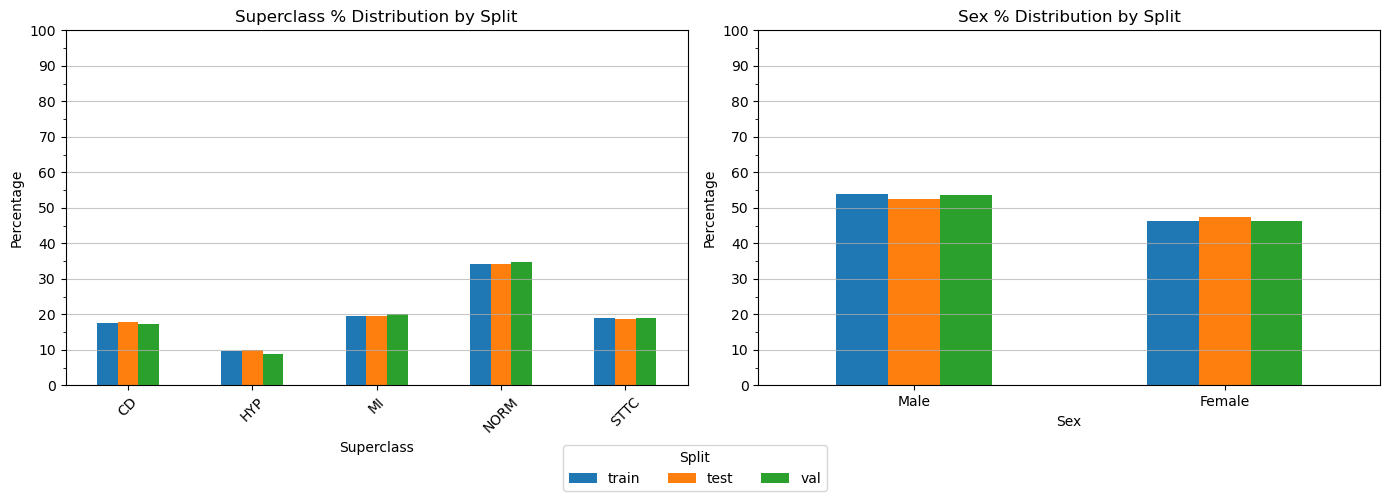

In [95]:
# Make sure your dataframe has a 'split' column ('train'/'test') and is exploded by superclass
verify_split_summary(df_exploded, label_col='superclasses', sex_col='sex_label', split_col='split')

In [96]:
# ----------------------------
# Table 3: Summary by Split
# ----------------------------

def generate_table3_concise(df, split_col='split', label_col='superclasses', sex_col='sex_label', top_n_classes=5):
    """
    Generate a concise summary table of cohort characteristics per split:
    - Total ECGs
    - Unique patients
    - Median age (IQR)
    - % Female
    - Top N superclasses (count + %)
    """
    table_rows = []
    split_order = ['train', 'test', 'val']
    
    for split in split_order:
        df_split = df[df[split_col] == split]
        n_records = len(df_split)
        n_patients = df_split['patient_id'].nunique()
        
        # Age
        age_median = df_split['age'].median()
        age_q1 = df_split['age'].quantile(0.25)
        age_q3 = df_split['age'].quantile(0.75)
        
        # Female %
        female_percent = (df_split[sex_col] == 'Female').mean() * 100
        
        # Top superclasses
        df_exploded = df_split[[label_col]].explode(label_col).dropna(subset=[label_col])
        class_counts = df_exploded[label_col].value_counts()
        class_percent = df_exploded[label_col].value_counts(normalize=True) * 100
        top_classes = [f"{cls}: {class_counts[cls]} ({class_percent[cls]:.1f}%)"
                       for cls in class_counts.index[:top_n_classes]]
        
        # Append split summary
        table_rows.append([
            split.capitalize(),
            n_records,
            n_patients,
            f"{age_median:.1f} ({age_q1:.1f}-{age_q3:.1f})",
            f"{female_percent:.1f}%",
            "; ".join(top_classes)
        ])
    
    table3 = pd.DataFrame(table_rows, columns=[
        "Split",
        "Total ECGs",
        "Unique Patients",
        "Median Age (IQR)",
        "% Female",
        f"Top {top_n_classes} Superclasses"
    ])
    return table3

# Generate concise Table 3
table3_concise = generate_table3_concise(df)
table3_concise

,Split,Total ECGs,Unique Patients,Median Age (IQR),% Female,Top 5 Superclasses
0,Train,15275,13208,61.0 (50.0-72.0),47.8%,NORM: 6667 (34.2%); MI: 3835 (19.7%); STTC: 36...
1,Test,3288,2831,62.5 (51.0-73.0),48.8%,NORM: 1423 (34.1%); MI: 813 (19.5%); STTC: 777...
2,Val,3236,2830,62.0 (50.0-72.0),47.5%,NORM: 1424 (34.9%); MI: 821 (20.1%); STTC: 772...


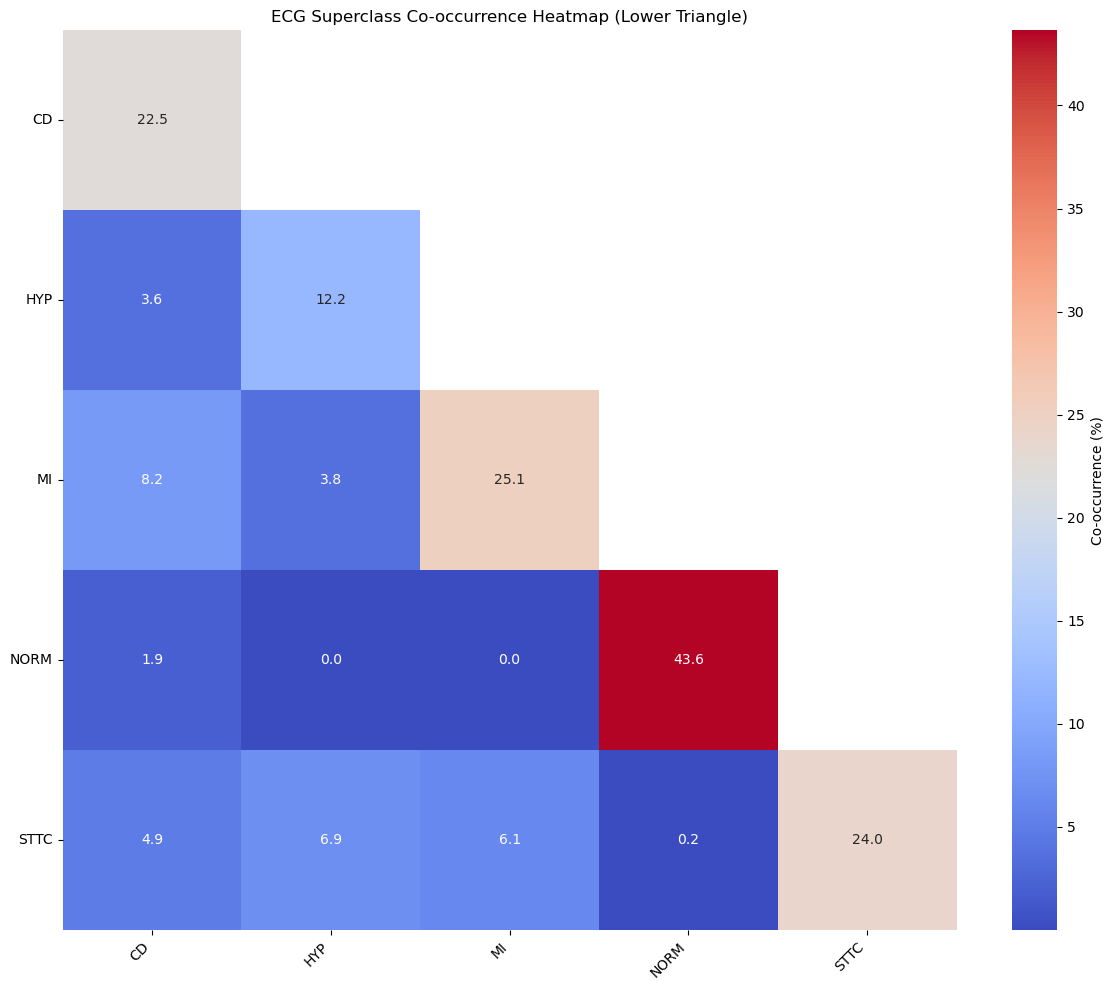

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Binarize superclasses
mlb = MultiLabelBinarizer()
superclass_matrix = mlb.fit_transform(df['superclasses'])

# 2. Create a DataFrame
superclass_df = pd.DataFrame(superclass_matrix, columns=mlb.classes_)

# 3. Compute co-occurrence matrix
co_occurrence = superclass_df.T @ superclass_df

# 4. Normalize to percentage
co_occurrence_percent = co_occurrence / len(df) * 100

# 5. Mask the upper triangle
mask = np.triu(np.ones_like(co_occurrence_percent, dtype=bool), k=1)

# 6. Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    co_occurrence_percent, 
    mask=mask,
    annot=True, 
    fmt=".1f", 
    cmap="coolwarm", 
    cbar_kws={'label': 'Co-occurrence (%)'}
)
plt.title("ECG Superclass Co-occurrence Heatmap (Lower Triangle)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [98]:
# ----------------------------
# Compute co-occurrence matrix
# ----------------------------
# Explode the superclasses column if not already
df_exploded = df[['patient_id', 'superclasses']].explode('superclasses').dropna(subset=['superclasses'])

# Create a binary presence matrix per patient
presence = df_exploded.groupby(['patient_id', 'superclasses']).size().unstack(fill_value=0)
presence = (presence > 0).astype(int)  # 1 if superclass exists for that patient

# Compute co-occurrence as % of patients
co_occurrence = presence.T.dot(presence) / presence.shape[0] * 100

print(co_occurrence)

superclasses         CD        HYP         MI       NORM       STTC
superclasses                                                       
CD            23.070312   4.082290   8.776924   2.658860   5.527206
HYP            4.082290  12.805500   4.189719   0.290057   7.278294
MI             8.776924   4.189719  25.084600   0.698287   6.918408
NORM           2.658860   0.290057   0.698287  47.784283   1.235430
STTC           5.527206   7.278294   6.918408   1.235430  24.585057


The diagonal shows class prevalence.

Off-diagonal shows real co-occurrences.

MI+CD at 8.2% is not negligible — it’s worth noting in discussion.